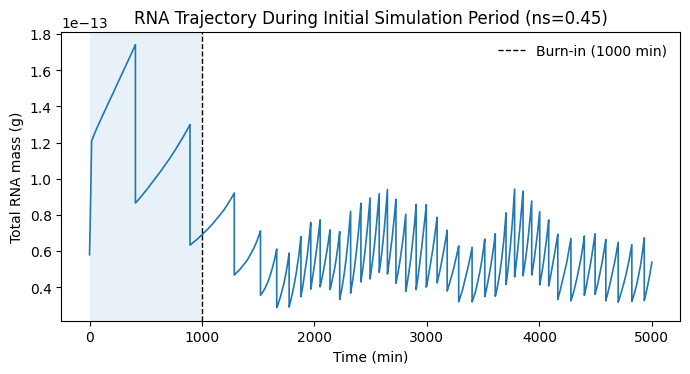

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

ARROW_FILE = "Data/ns045/abx0.arrow"

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

MW_NT = 330.0          # g/mol
NA = 6.022e23          # Avogadro

BURN_IN = 1000         # min
TIME_LIMIT = 5000      # min

plt.style.use("default")

# ============================================================
# LOAD DATA
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

df = load_arrow(ARROW_FILE)

# ============================================================
# RNA MASS CALCULATION
# ============================================================

def compute_rna_mass(df):

    # mRNA nucleotides
    NmRNA = (
        (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX) +
        (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX) +
        (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX) +
        (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)
    ).to_numpy()

    # total ribosome count
    Nribo = (
        df["r(t)"] +
        df["rmm(t)"] + df["rmt(t)"] + df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] + df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    # rRNA nucleotides
    NrRNA = Nribo * RIBO_RNA_NT

    # total RNA mass (grams)
    RNA_mass = (NmRNA + NrRNA) / NA * MW_NT

    return RNA_mass

df["RNA_mass_g"] = compute_rna_mass(df)

# ============================================================
# LIMIT TIME WINDOW
# ============================================================

df_plot = df[df["timestamp"] <= TIME_LIMIT]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(7,4))

plt.plot(
    df_plot["timestamp"],
    df_plot["RNA_mass_g"],
    linewidth=1.2
)

# Burn-in shading (cleaner than vertical line alone)
plt.axvspan(
    0,
    BURN_IN,
    alpha=0.1
)

plt.axvline(
    x=BURN_IN,
    linestyle="--",
    linewidth=1,
    color="black",
    label="Burn-in (1000 min)"
)

plt.xlabel("Time (min)")
plt.ylabel("Total RNA mass (g)")
plt.title("RNA Trajectory During Initial Simulation Period (ns=0.45)")

plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
BURN_IN = 1000

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000

# ============================================================
# LOAD
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ============================================================
# MASS + GROWTH
# ============================================================

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo
    return total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0  # 1/hr

# ============================================================
# ANALYSIS (abx = 0)
# ============================================================

results = []

for ns in NS_VALUES:

    path = f"Data/ns{int(ns*100):03d}/abx0.arrow"

    df = load_arrow(path)
    df = df[df["timestamp"] >= BURN_IN]

    total_mass = compute_mass_components(df)
    lam = compute_growth(df, total_mass)

    results.append({
        "ns_input": ns,
        "lambda_mean": np.mean(lam),
        "lambda_max": np.max(lam),
        "lambda_p95": np.percentile(lam, 95)
    })

df_check = pd.DataFrame(results)

print("\n=== ns vs growth statistics (abx = 0) ===\n")
print(df_check)


=== ns vs growth statistics (abx = 0) ===

   ns_input  lambda_mean  lambda_max  lambda_p95
0      0.45     0.419786    0.704180    0.547591
1      0.74     0.599876    0.983756    0.760530
2      1.03     0.729012    1.155120    0.915532
3      1.76     0.936438    1.347074    1.165791


In [7]:
import pyarrow as pa
import pyarrow.ipc as ipc
import pandas as pd

def load_arrow_head(filename, n=10):
    """Load an Arrow file and show the first n rows."""
    with pa.memory_map(filename, "r") as source:
        table = ipc.open_file(source).read_all()
    df = table.to_pandas()
    return df.head(n)

# Example:
df_head = load_arrow_head("ns045.arrow")
print(df_head)


   timestamp       si(t)           a(t)     mm(t)     mt(t)     mq(t)  \
0   0.000000  128.259856  149843.856663  0.011416  0.011416  1.328186   
1   0.166667  120.259856  149965.856663  0.011416  0.011416  3.328186   
2   0.333333  137.259856  150111.856663  0.011416  0.011416  1.328186   
3   0.500000  137.259856  150812.856663  0.011416 -0.988584  5.328186   
4   0.666667  136.259856  151809.856663  0.011416  0.011416  2.328186   
5   0.833333  115.259856  152422.856663  0.011416  0.011416  2.328186   
6   1.000000  135.259856  152496.856663  0.011416  0.011416  3.328186   
7   1.166667  159.259856  153534.856663  0.011416  0.011416  1.328186   
8   1.333333  105.259856  153922.856663 -0.988584  1.011416  3.328186   
9   1.500000  132.259856  152970.856663  0.011416  0.011416  4.328186   

      mr(t)         r(t)    rmm(t)    rmt(t)      rmq(t)     rmr(t)  \
0  0.017467  1643.959775  0.864048  0.864048  100.528348  15.687226   
1 -0.982533  1646.959775  0.864048  0.864048   98.5283

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import pyarrow as pa
import pyarrow.ipc as ipc

LAST_FRAC = 0.20      # last 20% for steady state if not auto-detected
ROLL_WIN = 51         # moving window for slope calc (odd number)
SLOPE_THR = 1e-4      # |slope| threshold to call “flat”/steady

# how to construct proxies (tweak to match your model semantics)
RNA_COLS   = ["mr(t)", "mt(t)", "mm(t)", "mq(t)","r(t), rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)","zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]           # sum as RNA proxy
PROT_COLS  = ["r(t)", "et(t)", "em(t)", "q(t)"]                     # ribosome count as protein proxy

TIME_COLS   = ["timestamp", "time", "t"]


In [8]:
# === Simulation Data Analysis Setup ===
# Works for files named like n_0.45.arrow, n_0.75.arrow, etc.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyarrow as pa
import pyarrow.ipc as ipc

# === Helper Functions ===



def compute_lambda(time: np.ndarray, signal: np.ndarray) -> float:
    """
    Estimate steady-state growth rate λ as slope of log(signal) vs time.
    Uses least-squares linear regression.
    """
    good = (signal > 0) & np.isfinite(signal)
    t, y = time[good], np.log(signal[good])
    if len(t) < 5:
        return np.nan
    A = np.vstack([np.ones_like(t), t]).T
    β, *_ = np.linalg.lstsq(A, y, rcond=None)
    return float(β[1])  # slope


def plot_growth_law(summary_df: pd.DataFrame):
    """
    Plot λ vs RNA/Protein ratio (growth law).
    """
    plt.figure(figsize=(6, 4))
    plt.scatter(summary_df["Ratio"], summary_df["lambda_ss"], s=80, color="tab:blue")
    plt.xlabel("RNA/Protein ratio (φR proxy)")
    plt.ylabel("Growth rate λ (1/h)")
    plt.title("Growth law across nutrient conditions")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_rna_protein(summary_df: pd.DataFrame):
    """
    Plot RNA vs Protein across nutrient conditions.
    """
    plt.figure(figsize=(6, 4))
    sc = plt.scatter(summary_df["Protein"], summary_df["RNA"],
                     c=summary_df["ns"], cmap="viridis", s=100)
    plt.colorbar(sc, label="Nutrient condition (ns)")
    plt.xlabel("Protein (proxy)")
    plt.ylabel("RNA (proxy)")
    plt.title("RNA vs Protein colored by ns")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


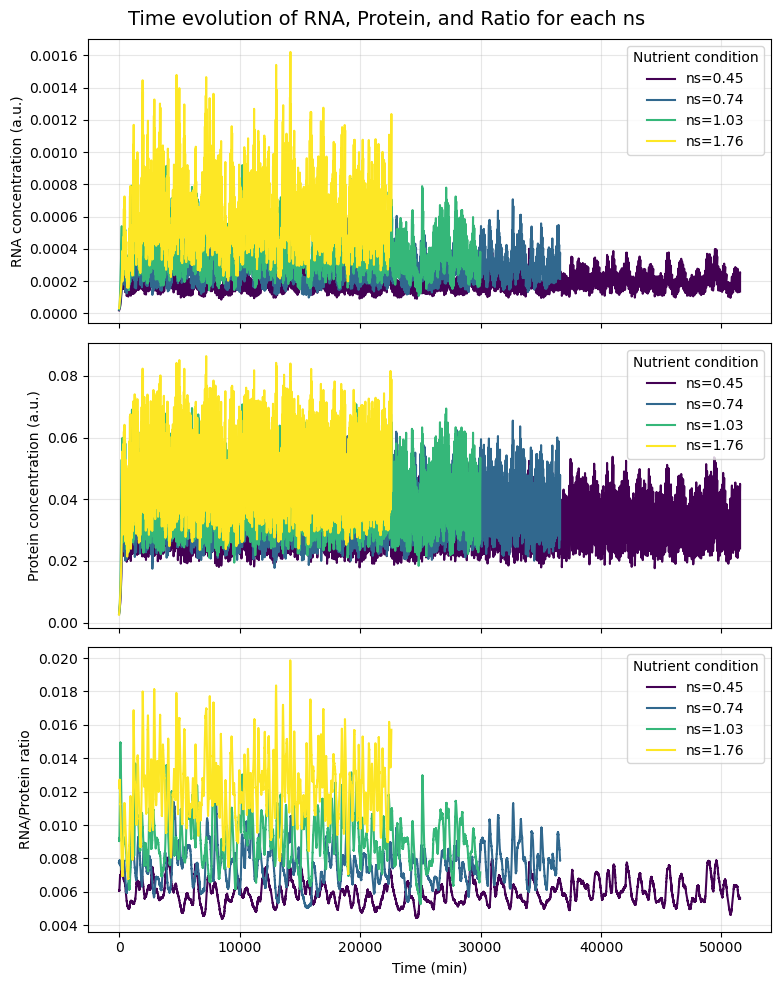

In [2]:
# === Time Series Plot of RNA, Protein, and Ratio for each ns ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --- Helper functions ---
def read_arrow(filename: str) -> pd.DataFrame:
    """Load .arrow file into pandas DataFrame."""
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def compute_rna_protein_ratio(df: pd.DataFrame):
    """Compute RNA, Protein, and Ratio time series."""
    time = df["timestamp"].values
    RNA = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)","r(t)", "rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)","zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    PROT = np.zeros(len(df))
    for c in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if c in df.columns: 
            PROT += df[c].values/1e8
    Ratio = RNA / np.where(PROT == 0, np.nan, PROT)
    return time, RNA, PROT, Ratio

# --- Hard-coded mapping: filename → ns value ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

# --- Plot setup ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    time, RNA, PROT, Ratio = compute_rna_protein_ratio(df)

    axes[0].plot(time, RNA, label=f"ns={ns}", color=color)
    axes[1].plot(time, PROT, label=f"ns={ns}", color=color)
    axes[2].plot(time, Ratio, label=f"ns={ns}", color=color)

# --- Formatting ---
axes[0].set_ylabel("RNA concentration (a.u.)")
axes[1].set_ylabel("Protein concentration (a.u.)")
axes[2].set_ylabel("RNA/Protein ratio")
axes[2].set_xlabel("Time (min)")

for ax in axes:
    ax.legend(title="Nutrient condition")
    ax.grid(alpha=0.3)

fig.suptitle("Time evolution of RNA, Protein, and Ratio for each ns", fontsize=14)
plt.tight_layout()
plt.show()




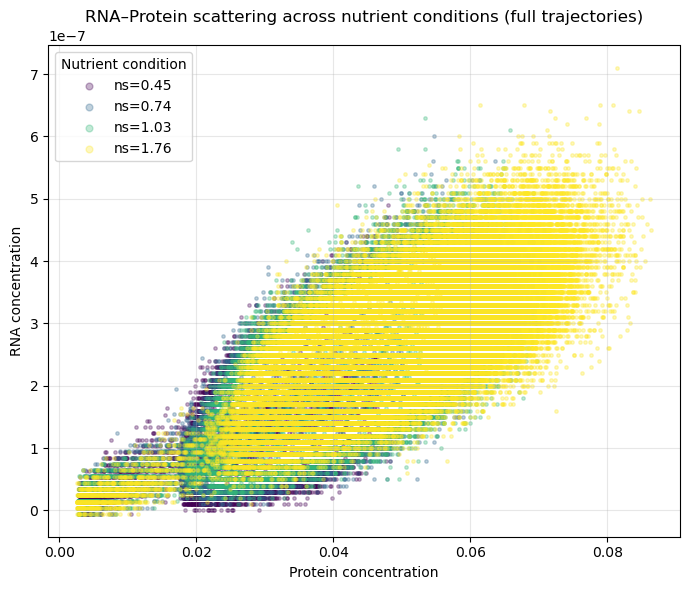

In [4]:
# === RNA–Protein scatter across full trajectories ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Return RNA and Protein for entire trajectory."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8     
    return RNA, PROT

# --- Hard-coded nutrient mapping ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

plt.figure(figsize=(7, 6))
for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    RNA, PROT = extract_rna_protein(df)

    plt.scatter(PROT, RNA, s=6, alpha=0.3, color=color, label=f"ns={ns:.2f}")


plt.xlabel("Protein concentration")
plt.ylabel("RNA concentration")
plt.title("RNA–Protein scattering across nutrient conditions (full trajectories)")
plt.legend(title="Nutrient condition", markerscale=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


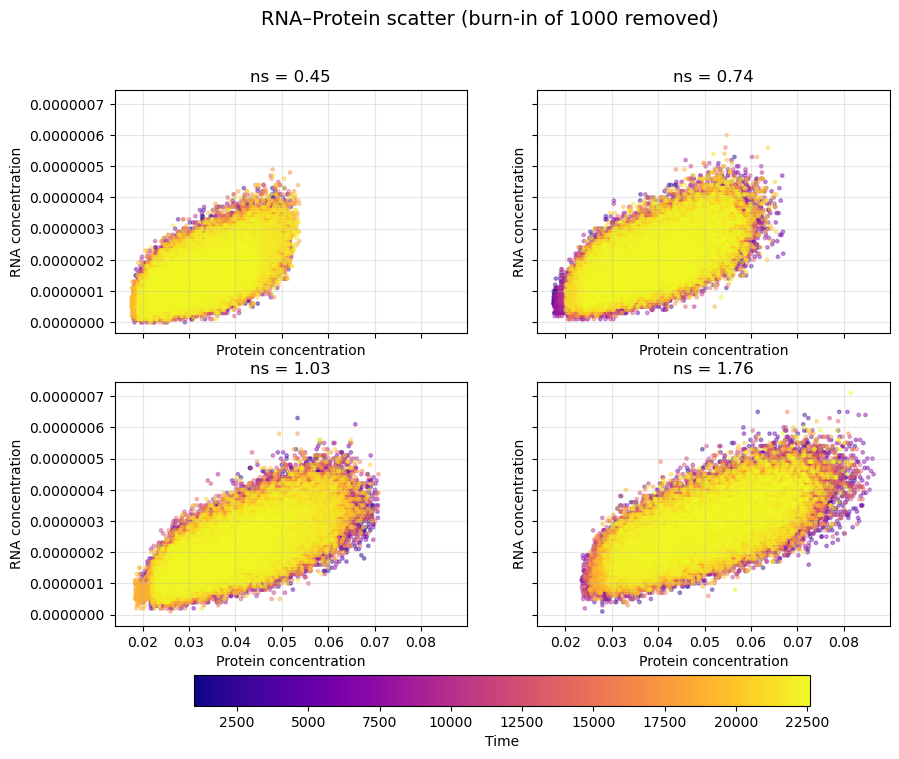

-0.008842091343361887
-0.013645070838910749


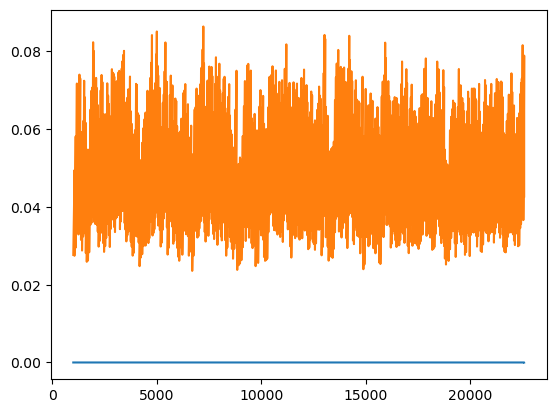

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Compute total RNA and Protein (free RNA definition)."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8
    return RNA, PROT

# --- Config ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

burn_in_time = 1000     
cmap = plt.cm.plasma    

# --- Create one axes per nutrient condition ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for (filename, ns), ax in zip(files_with_ns, axes):
    df = read_arrow(filename)

    # --- Drop burn-in points ---
    if "timestamp" not in df.columns:
        raise ValueError(f"File {filename} has no 't' column for time-gradient coloring.")

    df = df[df["timestamp"] >= burn_in_time].reset_index(drop=True)

    # --- Extract concentrations ---
    RNA, PROT = extract_rna_protein(df)
    T = df["timestamp"].values

    # --- Normalize time to [0,1] for colormap ---
    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    # --- Scatter plot with time gradient ---
    sc = ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)

    # Aesthetics
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein concentration")
    ax.set_ylabel("RNA concentration")
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
# Add a shared colourbar for time
norm = plt.Normalize(vmin=burn_in_time, vmax=df["timestamp"].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Time")


# Main title
fig.suptitle(
    f"RNA–Protein scatter (burn-in of {burn_in_time} removed)",
    fontsize=14
)



plt.show()
plt.plot(df["timestamp"], RNA)
plt.plot(df["timestamp"], PROT)
print(np.corrcoef(df["timestamp"], RNA)[0,1])
print(np.corrcoef(df["timestamp"], PROT)[0,1])


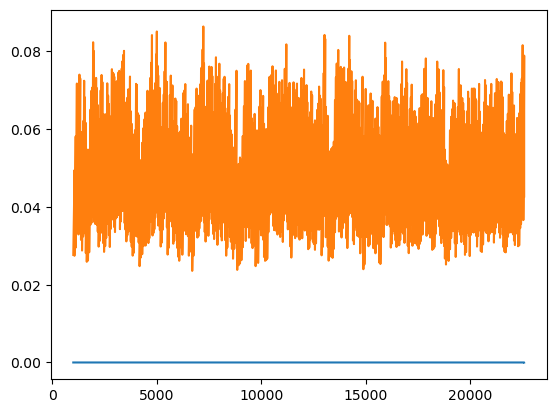

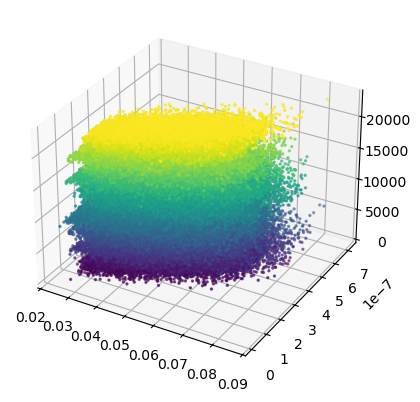

In [4]:
plt.plot(df["timestamp"], RNA)
plt.plot(df["timestamp"], PROT)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(PROT, RNA, T, c=T, s=2)



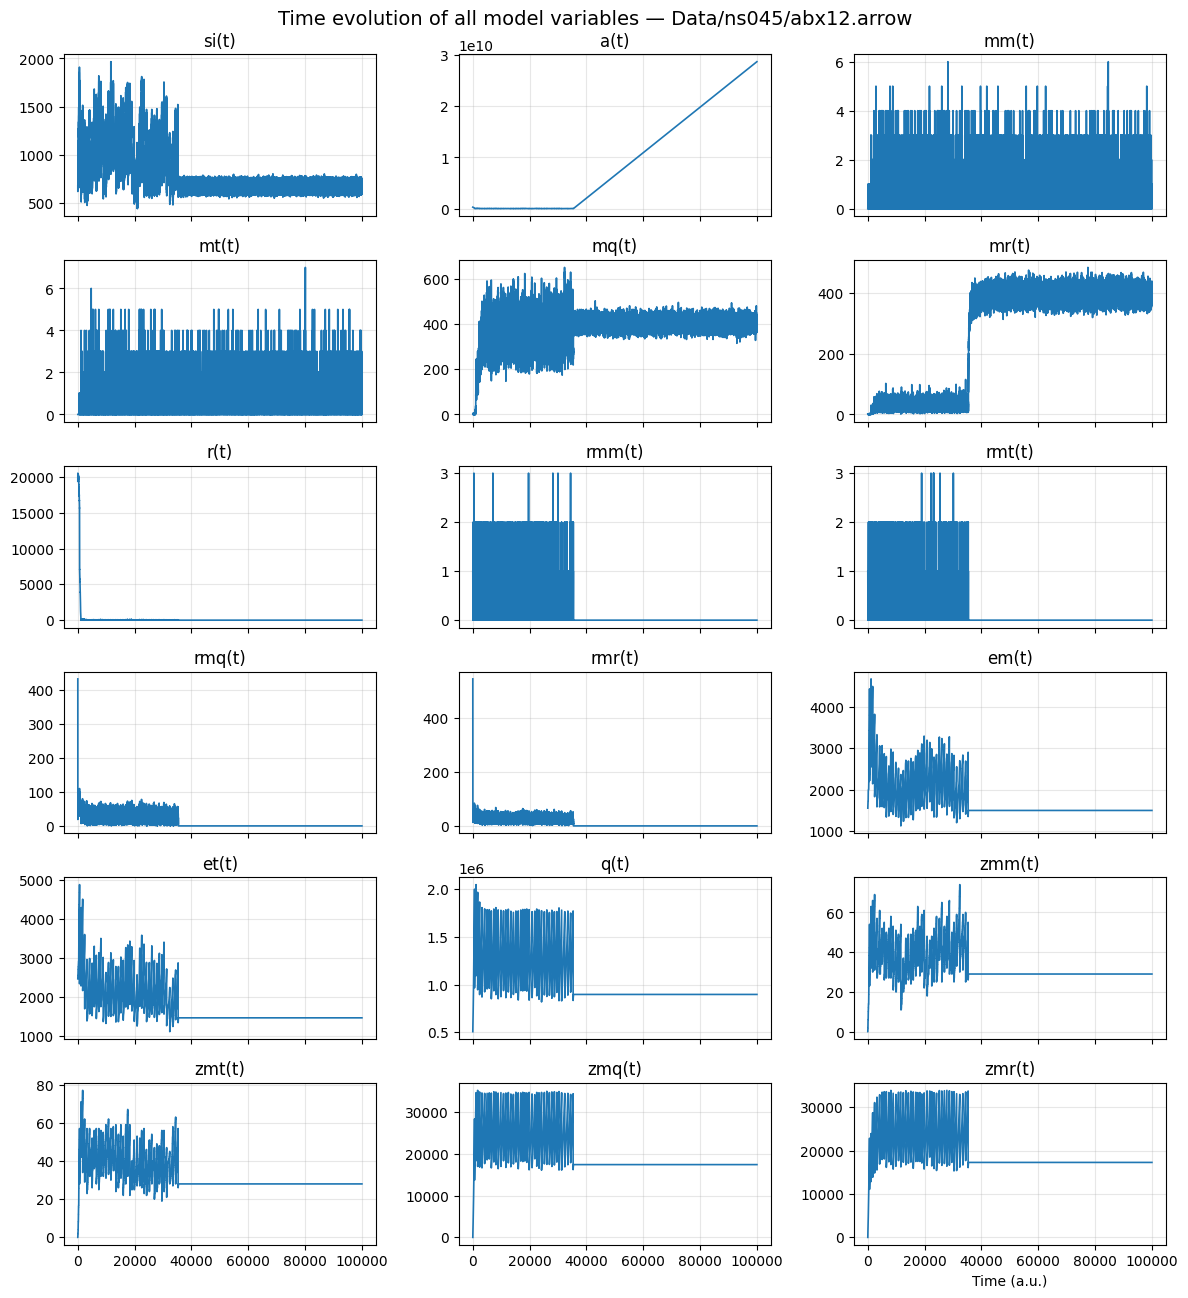

In [5]:
# === Plot all model variables over time for one ns file ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    """Load a .arrow file into a pandas DataFrame."""
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# --- choose file to visualize ---
filename = "Data/ns045/abx12.arrow"   # change to ns074, ns103, ns176 etc.

# --- load data ---
df = read_arrow(filename)

# --- define which columns to plot (excluding timestamp) ---
variables = [
    "si(t)", "a(t)", "mm(t)", "mt(t)", "mq(t)", "mr(t)",
    "r(t)", "rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)",
    "em(t)", "et(t)", "q(t)", "zmm(t)", "zmt(t)", "zmq(t)", "zmr(t)"
]

# keep only existing columns in your DataFrame
vars_present = [v for v in variables if v in df.columns]

time = df["timestamp"].values

# --- plot each variable over time ---
n = len(vars_present)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 2.2), sharex=True)
axes = axes.flatten()

for i, var in enumerate(vars_present):
    axes[i].plot(time, df[var], lw=1.2)
    axes[i].set_title(var)
    axes[i].grid(alpha=0.3)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[-1].set_xlabel("Time (a.u.)")
fig.suptitle(f"Time evolution of all model variables — {filename}", fontsize=14)
plt.tight_layout()
plt.show()


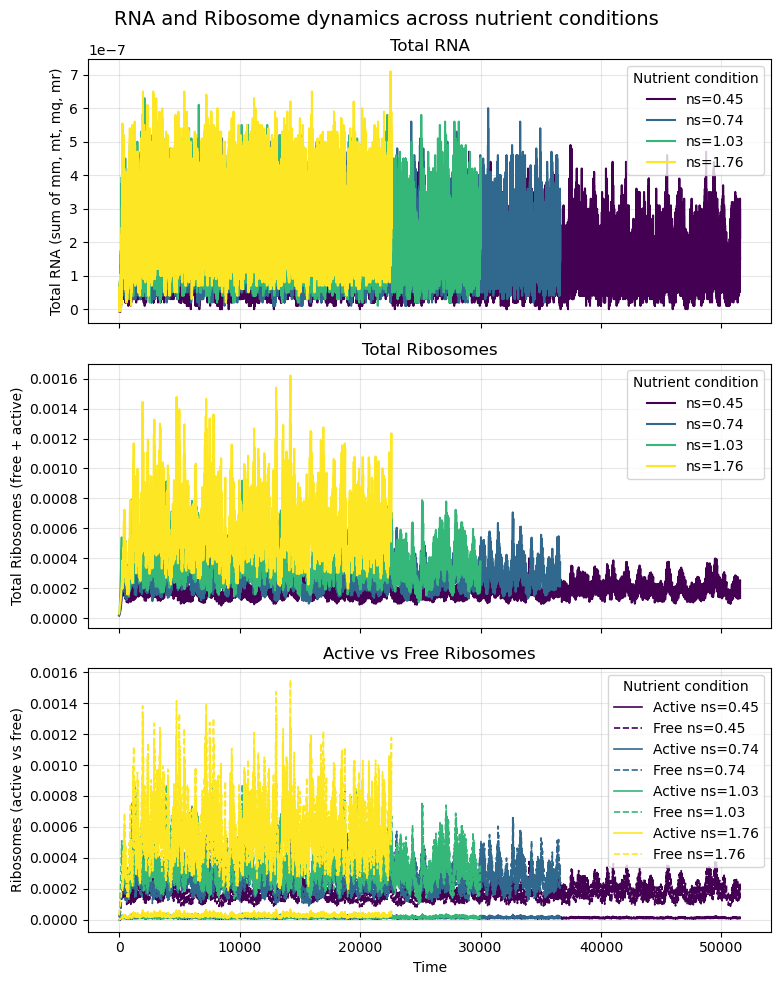

In [6]:
# === RNA & Ribosome dynamics across nutrient conditions ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    """Load .arrow file into pandas DataFrame."""
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def compute_rna_ribo(df):
    """Compute grouped RNA and ribosome totals."""
    n = len(df)
    RNA = np.zeros(n)
    for col in ["mm(t)", "mt(t)", "mq(t)", "mr(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8

    free_ribo = df["r(t)"].values/1e8
    active_ribo = np.zeros(n)
    for col in ["rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)"]:
        if col in df.columns:
            active_ribo += df[col].values/1e8

    total_ribo = free_ribo + active_ribo
    return RNA, total_ribo, free_ribo, active_ribo


# --- Hard-coded mapping of nutrient conditions ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

# --- Plot setup ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
labels = ["Total RNA", "Total Ribosomes", "Active vs Free Ribosomes"]

for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    time = df["timestamp"].values
    RNA, total_ribo, free_ribo, active_ribo = compute_rna_ribo(df)

    axes[0].plot(time, RNA, color=color, label=f"ns={ns}")
    axes[1].plot(time, total_ribo, color=color, label=f"ns={ns}")
    axes[2].plot(time, active_ribo, color=color, lw=1.2, label=f"Active ns={ns}")
    axes[2].plot(time, free_ribo, color=color, lw=1.2, linestyle="--", label=f"Free ns={ns}")

# --- Format plots ---
axes[0].set_ylabel("Total RNA (sum of mm, mt, mq, mr)")
axes[1].set_ylabel("Total Ribosomes (free + active)")
axes[2].set_ylabel("Ribosomes (active vs free)")
axes[2].set_xlabel("Time")

for ax, label in zip(axes, labels):
    ax.set_title(label)
    ax.legend(title="Nutrient condition")
    ax.grid(alpha=0.3)

fig.suptitle("RNA and Ribosome dynamics across nutrient conditions", fontsize=14)
plt.tight_layout()
plt.show()


== Mean ribosome levels over the whole run ==
ns=0.45:  mean(active)=1278.2,  mean(free)=17628.4
ns=0.74:  mean(active)=1625.4,  mean(free)=26048.2
ns=1.03:  mean(active)=1971.8,  mean(free)=34653.1
ns=1.76:  mean(active)=2829.9,  mean(free)=55189.0


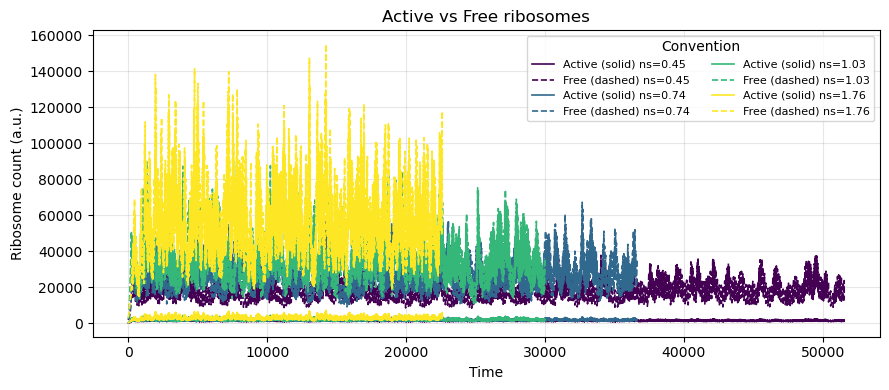

In [16]:
# --- sanity check + clear plot styles ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa, pyarrow.ipc as ipc

files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

def read_arrow(f):
    with pa.memory_map(f, "r") as s:
        return pa.ipc.open_file(s).read_all().to_pandas()

def get_ribo(df):
    free = df["r(t)"].to_numpy()
    active = sum(df[c].to_numpy() for c in ["rmm(t)","rmt(t)","rmq(t)","rmr(t)"] if c in df)
    return df["timestamp"].to_numpy(), free, active

# 1) Print quick aggregates so we know which is larger
print("== Mean ribosome levels over the whole run ==")
for f, ns in files_with_ns:
    df = read_arrow(f)
    _, free, active = get_ribo(df)
    print(f"ns={ns:.2f}:  mean(active)={active.mean():.1f},  mean(free)={free.mean():.1f}")

# 2) Replot with unambiguous styles/labels
colors = plt.cm.viridis(np.linspace(0,1,len(files_with_ns)))
plt.figure(figsize=(9,4))
for (f, ns), col in zip(files_with_ns, colors):
    t, free, active = get_ribo(read_arrow(f))
    # solid = ACTIVE, dashed = FREE (fixed)
    plt.plot(t, active, color=col, lw=1.2, label=f"Active (solid) ns={ns:.2f}")
    plt.plot(t, free,  color=col, lw=1.2, ls="--", label=f"Free (dashed) ns={ns:.2f}")

plt.title("Active vs Free ribosomes")
plt.xlabel("Time"); plt.ylabel("Ribosome count (a.u.)")
plt.legend(ncol=2, fontsize=8, title="Convention")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


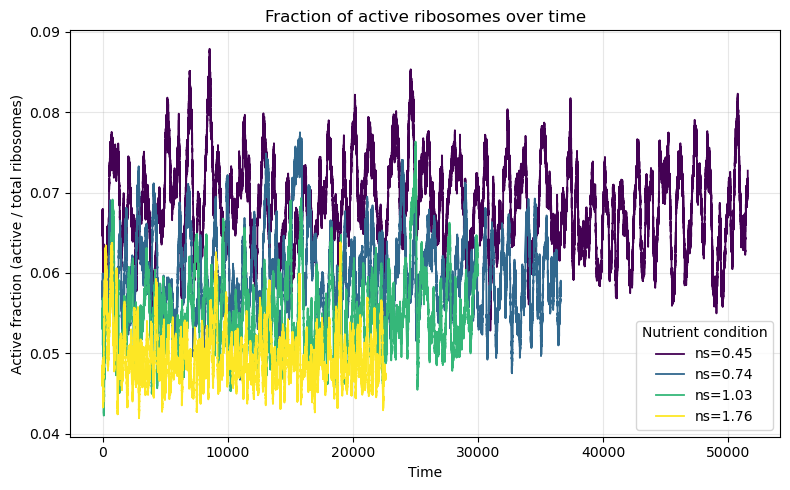

In [17]:
# === Fraction of active ribosomes over time ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa, pyarrow.ipc as ipc

def read_arrow(f):
    with pa.memory_map(f, "r") as s:
        return pa.ipc.open_file(s).read_all().to_pandas()

def compute_fraction(df):
    free = df["r(t)"].to_numpy()
    active = sum(df[c].to_numpy() for c in ["rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)"] if c in df)
    total = free + active
    frac = np.divide(active, total, out=np.zeros_like(active), where=total>0)
    return df["timestamp"].to_numpy(), frac

files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0,1,len(files_with_ns)))

plt.figure(figsize=(8,5))
for (f, ns), col in zip(files_with_ns, colors):
    df = read_arrow(f)
    t, frac = compute_fraction(df)
    plt.plot(t, frac, lw=1.3, color=col, label=f"ns={ns:.2f}")

plt.xlabel("Time")
plt.ylabel("Active fraction (active / total ribosomes)")
plt.title("Fraction of active ribosomes over time")
plt.legend(title="Nutrient condition")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


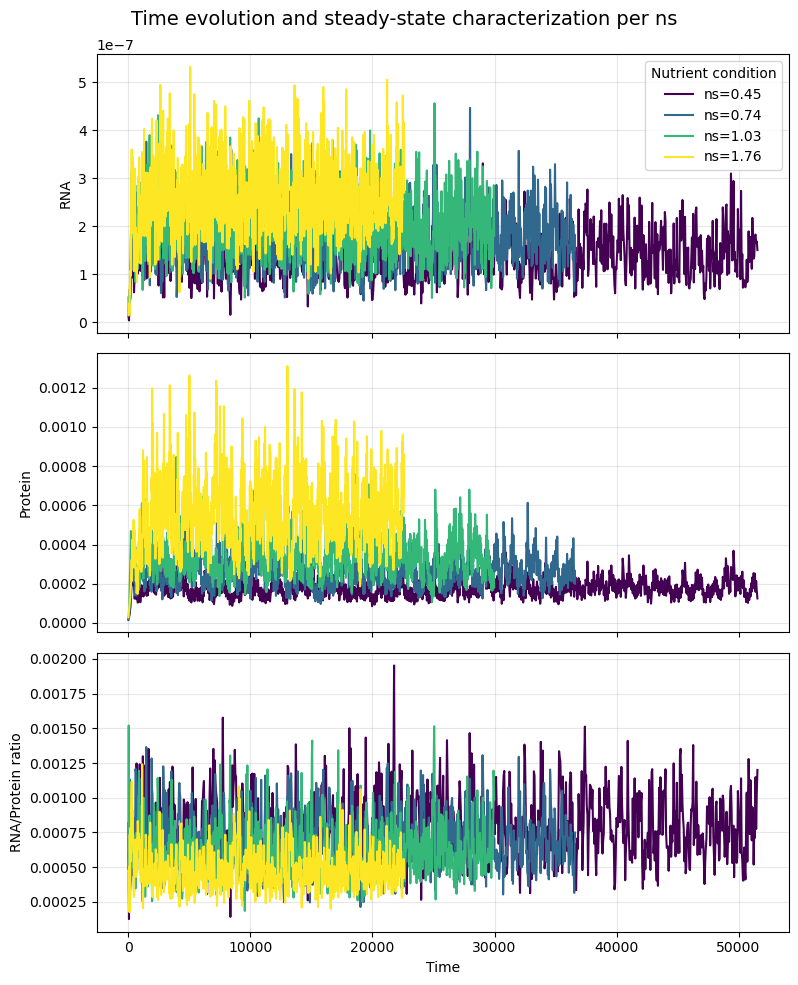

,ns,RNA_mean,RNA_std,Protein_mean,Protein_std,Ratio_mean,Ratio_std
0,0.45,1.416905e-07,5.208153e-08,0.000182,0.000049,0.000782,0.000219
1,0.74,1.844857e-07,5.714483e-08,0.000278,0.000082,0.000681,0.000181
2,1.03,2.026832e-07,6.728839e-08,0.000328,0.000114,0.000644,0.000191
3,1.76,2.575864e-07,6.758672e-08,0.000555,0.000169,0.000486,0.000127


In [7]:
# === Characterize steady-state behavior for each nutrient condition ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename):
    with pa.memory_map(filename, "r") as src:
        return pa.ipc.open_file(src).read_all().to_pandas()

def compute_rna_protein_ratio(df):
    """Compute RNA, Protein, Ratio, and even sampling."""
    RNA = np.zeros(len(df))
    for c in ["mq(t)", "mr(t)"]:
        if c in df.columns:
            RNA += df[c].values/1e8
    Protein = df["r(t)"].values/1e8
    Ratio = np.divide(RNA, Protein, out=np.zeros_like(RNA), where=Protein>0)
    return df["timestamp"].values, RNA, Protein, Ratio

def steady_state_stats(time, values, frac=0.2):
    """Return steady-state mean and std from last `frac` portion of data."""
    k0 = int((1 - frac) * len(values))
    ss_values = values[k0:]
    return np.mean(ss_values), np.std(ss_values)

# Hard-coded mapping
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))
summaries = []

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
labels = ["RNA", "Protein", "RNA/Protein ratio"]

for (file, ns), color in zip(files_with_ns, colors):
    df = read_arrow(file)
    t, RNA, Protein, Ratio = compute_rna_protein_ratio(df)

    # Equal-distance resampling (1000 uniform points)
    t_resampled = np.linspace(t.min(), t.max(), 1000)
    RNA_resampled = np.interp(t_resampled, t, RNA)
    Protein_resampled = np.interp(t_resampled, t, Protein)
    Ratio_resampled = np.interp(t_resampled, t, Ratio)

    # Compute steady-state stats
    RNA_mean, RNA_std = steady_state_stats(t_resampled, RNA_resampled)
    Prot_mean, Prot_std = steady_state_stats(t_resampled, Protein_resampled)
    Ratio_mean, Ratio_std = steady_state_stats(t_resampled, Ratio_resampled)

    summaries.append(dict(ns=ns,
                          RNA_mean=RNA_mean, RNA_std=RNA_std,
                          Protein_mean=Prot_mean, Protein_std=Prot_std,
                          Ratio_mean=Ratio_mean, Ratio_std=Ratio_std))

    # Plot over time
    axes[0].plot(t_resampled, RNA_resampled, color=color, label=f"ns={ns}")
    axes[1].plot(t_resampled, Protein_resampled, color=color)
    axes[2].plot(t_resampled, Ratio_resampled, color=color)

for i, label in enumerate(labels):
    axes[i].set_ylabel(label)
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel("Time")
axes[0].legend(title="Nutrient condition")

plt.suptitle("Time evolution and steady-state characterization per ns", fontsize=14)
plt.tight_layout()
plt.show()

# === Summary table ===
summary_df = pd.DataFrame(summaries)
display(summary_df)


AttributeError: This method only works with the ScalarFormatter

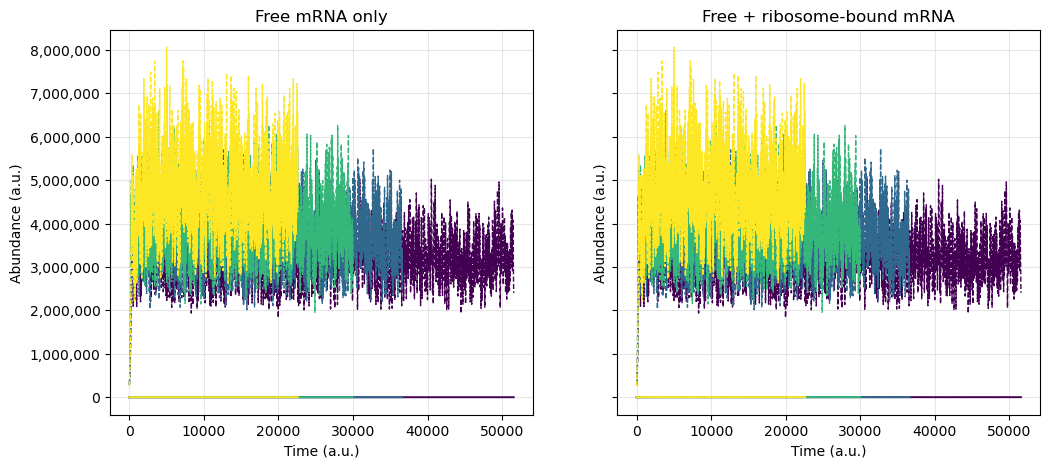

In [9]:
# === Compare RNA totals (free vs free+bound) alongside total protein ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.ticker as mticker

def read_arrow(filename):
    with pa.memory_map(filename, "r") as src:
        return pa.ipc.open_file(src).read_all().to_pandas()

def compute_rna_protein(df, include_bound=False):
    """Compute total RNA (optionally including bound) and total protein."""
    # --- RNA: free mRNAs ---
    RNA = np.zeros(len(df))
    for c in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if c in df.columns:
            RNA += df[c].values

    # --- Optionally add bound ribosome-mRNA complexes ---
    if include_bound:
        for c in ["rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)"]:
            if c in df.columns:
                RNA += df[c].values

    # --- Protein: total mature proteins ---
    Protein = np.zeros(len(df))
    for c in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if c in df.columns:
            Protein += df[c].values

    return df["timestamp"].values, RNA, Protein


# --- Nutrient conditions and colours ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]
colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

# --- Burn-in time (optional, can shade later if wanted) ---
BURN_IN_TIME = 10000

# --- Plot: RNA free vs RNA free+bound, plus protein ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
titles = ["Free mRNA only", "Free + ribosome-bound mRNA"]

for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)

    # Compute both RNA totals and protein
    t, RNA_free, Protein = compute_rna_protein(df, include_bound=False)
    _, RNA_bound, _ = compute_rna_protein(df, include_bound=True)

    # Uniform resampling for smoother plots
    t_res = np.linspace(t.min(), t.max(), 1000)
    RNA_free_res = np.interp(t_res, t, RNA_free)
    RNA_bound_res = np.interp(t_res, t, RNA_bound)
    Protein_res = np.interp(t_res, t, Protein)

    # --- Left panel: Free RNA vs Protein ---
    axes[0].plot(t_res, RNA_free_res, color=color, lw=1.4, label=f"RNA ns={ns}")
    axes[0].plot(t_res, Protein_res, color=color, lw=1.0, ls="--", label=f"Protein ns={ns}")

    # --- Right panel: Free+Bound RNA vs Protein ---
    axes[1].plot(t_res, RNA_bound_res, color=color, lw=1.4, label=f"RNA ns={ns}")
    axes[1].plot(t_res, Protein_res, color=color, lw=1.0, ls="--", label=f"Protein ns={ns}")

# --- Axis formatting ---
for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Time (a.u.)")
    ax.set_ylabel("Abundance (a.u.)")
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')   # disable 1e6 notation
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))  # commas for readability

axes[0].legend(title="Nutrient condition", fontsize=8, ncol=2)
fig.suptitle("RNA (free vs free+bound) and Protein over time", fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import pyarrow as pa
import pyarrow.ipc as ipc

LAST_FRAC = 0.20      # last 20% for steady state if not auto-detected
ROLL_WIN = 51         # moving window for slope calc (odd number)
SLOPE_THR = 1e-4      # |slope| threshold to call “flat”/steady

# how to construct proxies (tweak to match your model semantics)
RNA_COLS   = ["mr(t)", "mt(t)", "mm(t)", "mq(t)","r(t), rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)","zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]           # sum as RNA proxy
PROT_COLS  = ["r(t)", "et(t)", "em(t)", "q(t)"]                     # ribosome count as protein proxy

TIME_COLS   = ["timestamp", "time", "t"]


In [8]:
# === Simulation Data Analysis Setup ===
# Works for files named like n_0.45.arrow, n_0.75.arrow, etc.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyarrow as pa
import pyarrow.ipc as ipc

# === Helper Functions ===



def compute_lambda(time: np.ndarray, signal: np.ndarray) -> float:
    """
    Estimate steady-state growth rate λ as slope of log(signal) vs time.
    Uses least-squares linear regression.
    """
    good = (signal > 0) & np.isfinite(signal)
    t, y = time[good], np.log(signal[good])
    if len(t) < 5:
        return np.nan
    A = np.vstack([np.ones_like(t), t]).T
    β, *_ = np.linalg.lstsq(A, y, rcond=None)
    return float(β[1])  # slope


def plot_growth_law(summary_df: pd.DataFrame):
    """
    Plot λ vs RNA/Protein ratio (growth law).
    """
    plt.figure(figsize=(6, 4))
    plt.scatter(summary_df["Ratio"], summary_df["lambda_ss"], s=80, color="tab:blue")
    plt.xlabel("RNA/Protein ratio (φR proxy)")
    plt.ylabel("Growth rate λ (1/h)")
    plt.title("Growth law across nutrient conditions")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_rna_protein(summary_df: pd.DataFrame):
    """
    Plot RNA vs Protein across nutrient conditions.
    """
    plt.figure(figsize=(6, 4))
    sc = plt.scatter(summary_df["Protein"], summary_df["RNA"],
                     c=summary_df["ns"], cmap="viridis", s=100)
    plt.colorbar(sc, label="Nutrient condition (ns)")
    plt.xlabel("Protein (proxy)")
    plt.ylabel("RNA (proxy)")
    plt.title("RNA vs Protein colored by ns")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


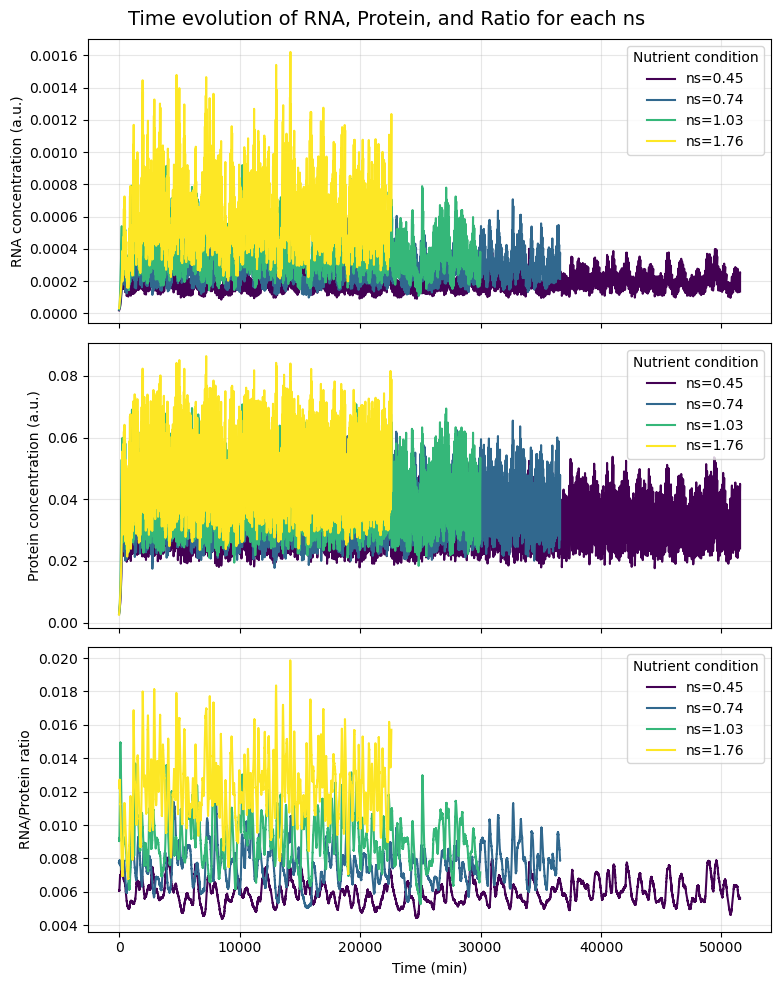

In [2]:
# === Time Series Plot of RNA, Protein, and Ratio for each ns ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# --- Helper functions ---
def read_arrow(filename: str) -> pd.DataFrame:
    """Load .arrow file into pandas DataFrame."""
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def compute_rna_protein_ratio(df: pd.DataFrame):
    """Compute RNA, Protein, and Ratio time series."""
    time = df["timestamp"].values
    RNA = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)","r(t)", "rmr(t)", "rmt(t)", "rmm(t)", "rmq(t)","zmr(t)", "zmt(t)", "zmm(t)", "zmq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    PROT = np.zeros(len(df))
    for c in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if c in df.columns: 
            PROT += df[c].values/1e8
    Ratio = RNA / np.where(PROT == 0, np.nan, PROT)
    return time, RNA, PROT, Ratio

# --- Hard-coded mapping: filename → ns value ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

# --- Plot setup ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    time, RNA, PROT, Ratio = compute_rna_protein_ratio(df)

    axes[0].plot(time, RNA, label=f"ns={ns}", color=color)
    axes[1].plot(time, PROT, label=f"ns={ns}", color=color)
    axes[2].plot(time, Ratio, label=f"ns={ns}", color=color)

# --- Formatting ---
axes[0].set_ylabel("RNA concentration (a.u.)")
axes[1].set_ylabel("Protein concentration (a.u.)")
axes[2].set_ylabel("RNA/Protein ratio")
axes[2].set_xlabel("Time (min)")

for ax in axes:
    ax.legend(title="Nutrient condition")
    ax.grid(alpha=0.3)

fig.suptitle("Time evolution of RNA, Protein, and Ratio for each ns", fontsize=14)
plt.tight_layout()
plt.show()




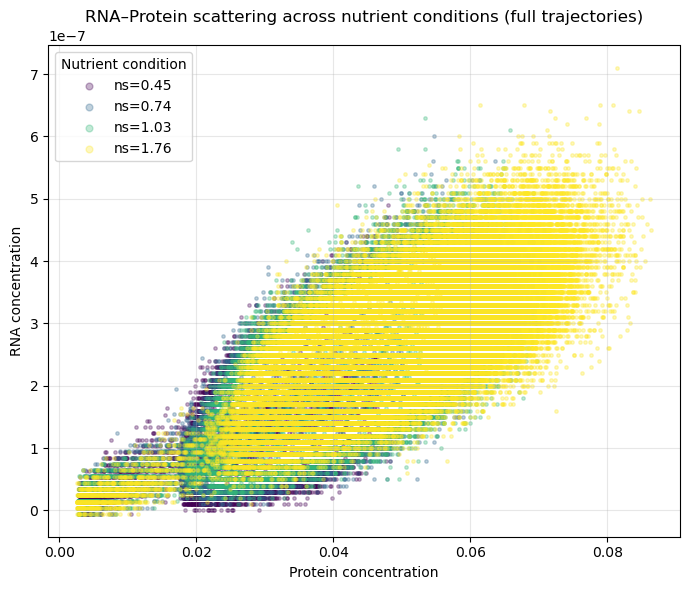

In [4]:
# === RNA–Protein scatter across full trajectories ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Return RNA and Protein for entire trajectory."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8     
    return RNA, PROT

# --- Hard-coded nutrient mapping ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

plt.figure(figsize=(7, 6))
for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    RNA, PROT = extract_rna_protein(df)

    plt.scatter(PROT, RNA, s=6, alpha=0.3, color=color, label=f"ns={ns:.2f}")


plt.xlabel("Protein concentration")
plt.ylabel("RNA concentration")
plt.title("RNA–Protein scattering across nutrient conditions (full trajectories)")
plt.legend(title="Nutrient condition", markerscale=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


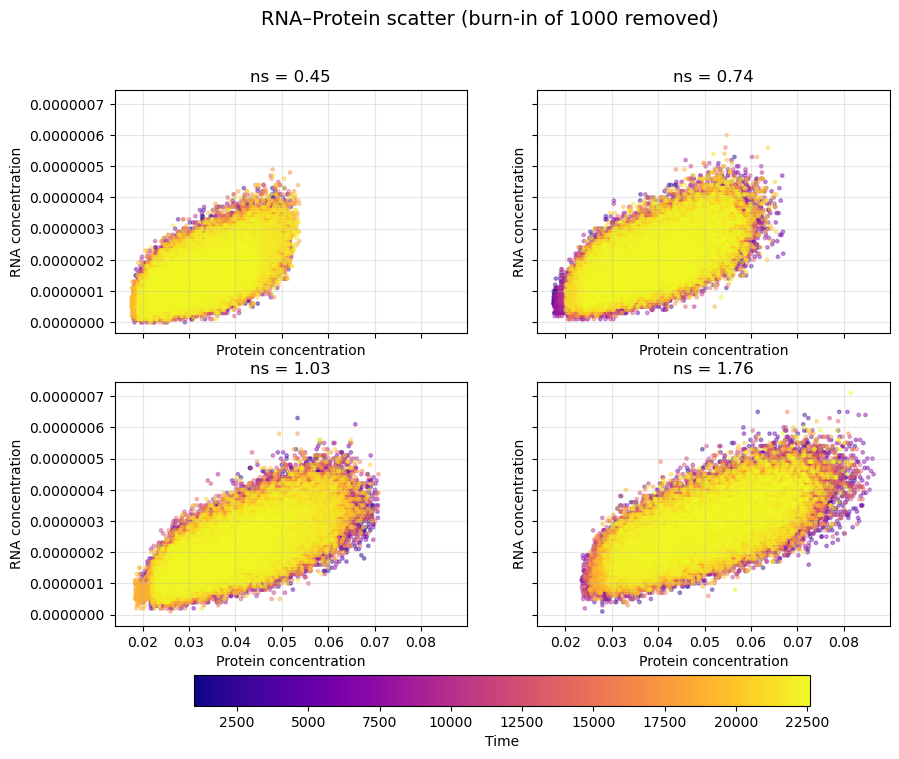

-0.008842091343361887
-0.013645070838910749


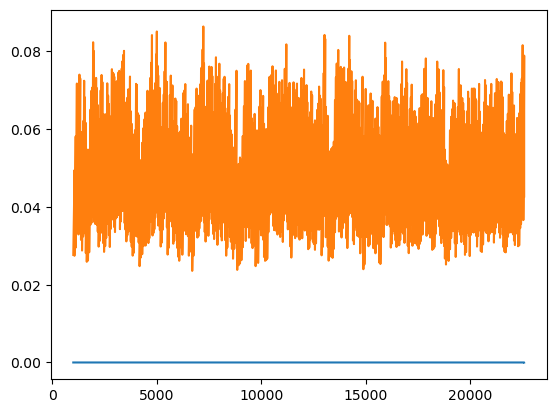

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Compute total RNA and Protein (free RNA definition)."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8
    return RNA, PROT

# --- Config ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

burn_in_time = 1000     
cmap = plt.cm.plasma    

# --- Create one axes per nutrient condition ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for (filename, ns), ax in zip(files_with_ns, axes):
    df = read_arrow(filename)

    # --- Drop burn-in points ---
    if "timestamp" not in df.columns:
        raise ValueError(f"File {filename} has no 't' column for time-gradient coloring.")

    df = df[df["timestamp"] >= burn_in_time].reset_index(drop=True)

    # --- Extract concentrations ---
    RNA, PROT = extract_rna_protein(df)
    T = df["timestamp"].values

    # --- Normalize time to [0,1] for colormap ---
    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    # --- Scatter plot with time gradient ---
    sc = ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)

    # Aesthetics
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein concentration")
    ax.set_ylabel("RNA concentration")
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
# Add a shared colourbar for time
norm = plt.Normalize(vmin=burn_in_time, vmax=df["timestamp"].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Time")


# Main title
fig.suptitle(
    f"RNA–Protein scatter (burn-in of {burn_in_time} removed)",
    fontsize=14
)



plt.show()
plt.plot(df["timestamp"], RNA)
plt.plot(df["timestamp"], PROT)
print(np.corrcoef(df["timestamp"], RNA)[0,1])
print(np.corrcoef(df["timestamp"], PROT)[0,1])


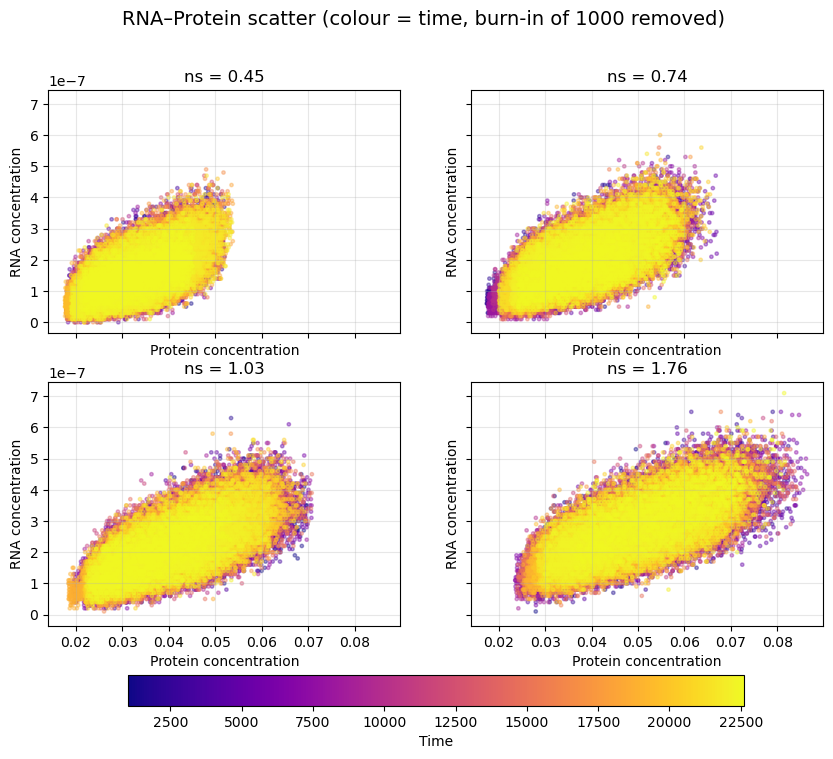

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

def extract_rna_protein(df):
    """Compute total RNA and Protein (free RNA definition)."""
    RNA = np.zeros(len(df))
    PROT = np.zeros(len(df))
    for col in ["mr(t)", "mt(t)", "mm(t)", "mq(t)"]:
        if col in df.columns:
            RNA += df[col].values/1e8
    for col in ["r(t)", "et(t)", "em(t)", "q(t)"]:
        if col in df.columns:
            PROT += df[col].values/1e8
    return RNA, PROT

# --- Config ---
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

burn_in_time = 1000   # <<< YOUR CHOSEN BURN-IN
cmap = plt.cm.plasma

# --- Create subplots ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for (filename, ns), ax in zip(files_with_ns, axes):
    df = read_arrow(filename)

    # --- REMOVE ALL BURN-IN POINTS USING THE CORRECT TIME COLUMN ---
    if "timestamp" not in df.columns:
        raise ValueError(f"{filename} has no timestamp column.")

    df = df[df["timestamp"] >= burn_in_time].reset_index(drop=True)

    # Extract concentrations *after* filtering
    RNA, PROT = extract_rna_protein(df)
    T = df["timestamp"].values

    # Time → colour gradient
    T_norm = (T - T.min()) / (T.max() - T.min() + 1e-12)
    colors = cmap(T_norm)

    ax.scatter(PROT, RNA, s=6, alpha=0.4, c=colors)
    ax.set_title(f"ns = {ns:.2f}")
    ax.set_xlabel("Protein concentration")
    ax.set_ylabel("RNA concentration")
    ax.grid(alpha=0.3)

# --- Shared colourbar (time scale) ---
norm = plt.Normalize(vmin=burn_in_time, vmax=T.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Time")

# Title
fig.suptitle(
    f"RNA–Protein scatter (colour = time, burn-in of {burn_in_time} removed)",
    fontsize=14
)


plt.show()


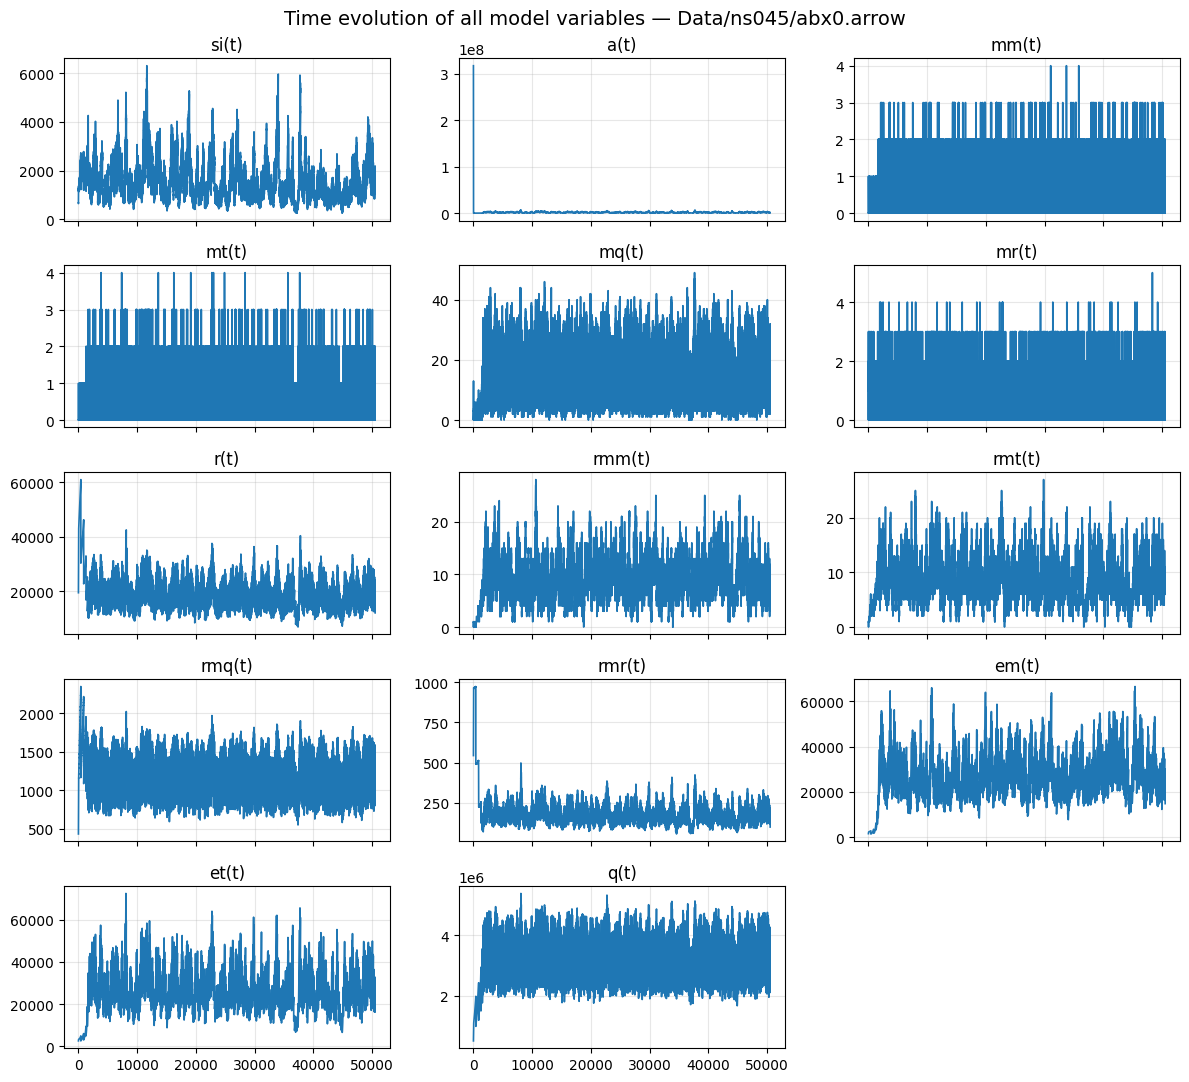

In [11]:
# === Plot all model variables over time for one ns file ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename: str):
    """Load a .arrow file into a pandas DataFrame."""
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# --- choose file to visualize ---
filename = "Data/ns045/abx0.arrow"   # change to ns074, ns103, ns176 etc.

# --- load data ---
df = read_arrow(filename)

# --- define which columns to plot (excluding timestamp) ---
variables = [
    "si(t)", "a(t)", "mm(t)", "mt(t)", "mq(t)", "mr(t)",
    "r(t)", "rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)",
    "em(t)", "et(t)", "q(t)"
]

# keep only existing columns in your DataFrame
vars_present = [v for v in variables if v in df.columns]
# vars_present = [v for v in vars_present if v < 0]

time = df["timestamp"].values

# --- plot each variable over time ---
n = len(vars_present)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 2.2), sharex=True)
axes = axes.flatten()

for i, var in enumerate(vars_present):
    axes[i].plot(time, df[var], lw=1.2)
    axes[i].set_title(var)
    axes[i].grid(alpha=0.3)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[-1].set_xlabel("Time (a.u.)")
fig.suptitle(f"Time evolution of all model variables — {filename}", fontsize=14)
plt.tight_layout()
plt.show()



=== Negative-value summary ===
  variable  min_value  num_negative  first_time   last_time
0    mm(t)  -0.988584           374    1.333333  317.000000
1    mt(t)  -0.988584           195    0.500000  318.500000
3    mr(t)  -0.982533           330    0.166667  319.333333
2    mq(t)  -0.671814            15    9.000000  147.833333
4   rmm(t)  -0.135952            31    2.000000  140.333333
5   rmt(t)  -0.135952             5    1.333333   10.500000


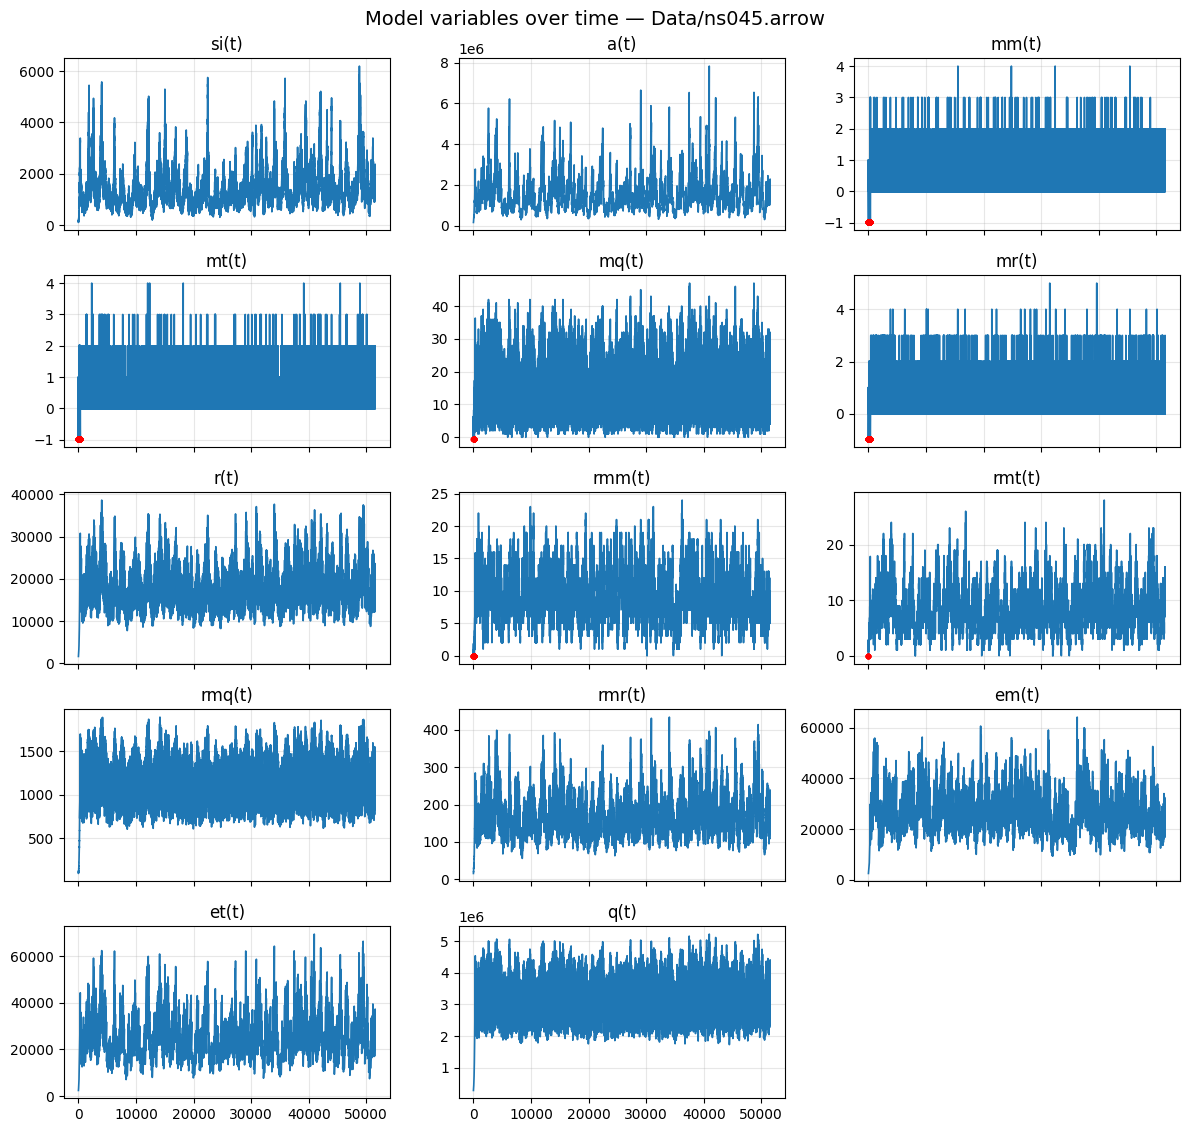

In [1]:
# === Plot all model variables over time & diagnose negatives ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
import pandas as pd

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ------------------------------------------------------------
# Choose file
# ------------------------------------------------------------
filename = "Data/ns045.arrow"   # change as needed
df = read_arrow(filename)

time = df["timestamp"].values

# ------------------------------------------------------------
# Variables to inspect
# ------------------------------------------------------------
variables = [
    "si(t)", "a(t)",
    "mm(t)", "mt(t)", "mq(t)", "mr(t)",
    "r(t)", "rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)",
    "em(t)", "et(t)", "q(t)"
]

vars_present = [v for v in variables if v in df.columns]

# ------------------------------------------------------------
# Diagnose negatives
# ------------------------------------------------------------
negative_summary = []

for var in vars_present:
    values = df[var].values
    neg_mask = values < 0

    if np.any(neg_mask):
        negative_summary.append({
            "variable": var,
            "min_value": values.min(),
            "num_negative": np.sum(neg_mask),
            "first_time": time[neg_mask][0],
            "last_time": time[neg_mask][-1]
        })

neg_df = pd.DataFrame(negative_summary)

print("\n=== Negative-value summary ===")
if neg_df.empty:
    print("No negative values detected.")
else:
    print(neg_df.sort_values("min_value"))

# ------------------------------------------------------------
# Plot time series with negatives highlighted
# ------------------------------------------------------------
n = len(vars_present)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, nrows * 2.3),
    sharex=True
)
axes = axes.flatten()

for i, var in enumerate(vars_present):
    y = df[var].values
    axes[i].plot(time, y, lw=1.2, color="tab:blue")

    # Highlight negative values
    neg = y < 0
    if np.any(neg):
        axes[i].scatter(
            time[neg], y[neg],
            color="red", s=10, zorder=3,
            label="negative"
        )

    axes[i].set_title(var)
    axes[i].grid(alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[-1].set_xlabel("Time (min)")
fig.suptitle(f"Model variables over time — {filename}", fontsize=14)
plt.tight_layout()
plt.show()


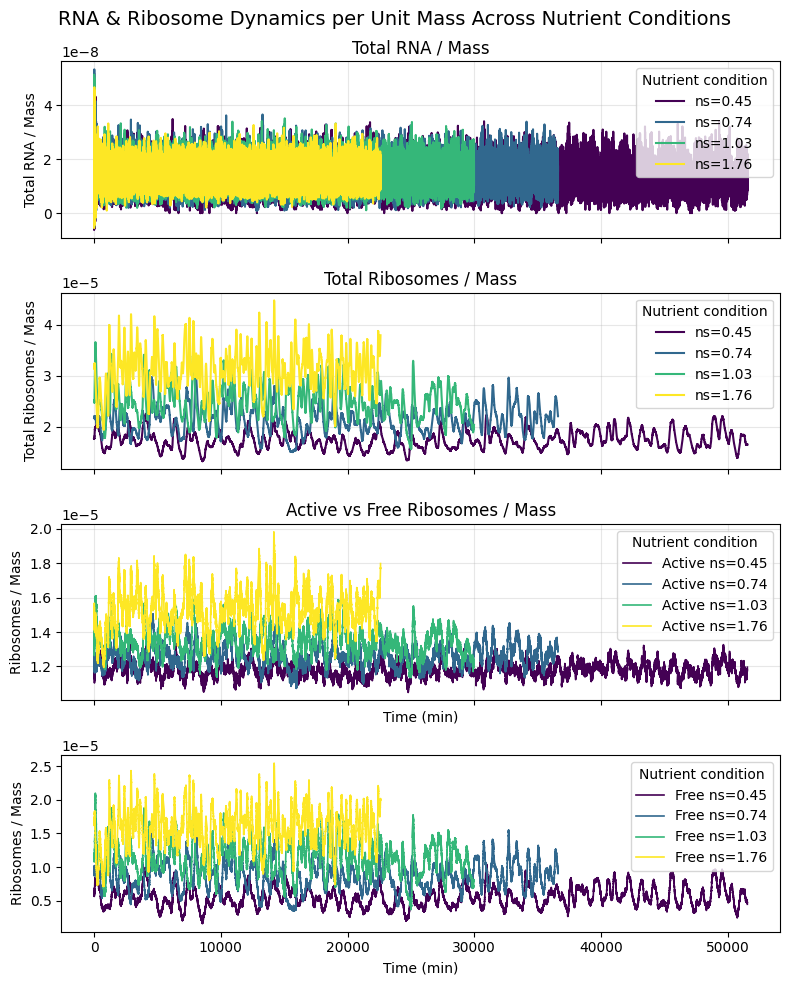

In [ ]:
# === RNA & Ribosome dynamics across nutrient conditions (normalized by mass) ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ---------- CONSTANTS ----------
NR = 7549.0      # ribosomal protein size
NX = 300.0       # average non-ribosomal protein size

# ---------- Load Arrow ----------
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ---------- Compute Total Mass ----------
def compute_mass(df):
    """Reproduce the exact mass definition used in the stochastic model."""
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo_mass
    return total_mass

# ---------- Compute RNA + Ribosomes ----------
def compute_rna_ribo(df, mass):
    n = len(df)
    RNA = np.zeros(n)
    for col in ["mm(t)", "mt(t)", "mq(t)", "mr(t)"]:
        RNA += df[col].values / mass   # <-- NORMALIZED BY MASS

    free_ribo = df["r(t)"].values / mass
    active_ribo = (
        df["rmm(t)"].values +
        df["rmt(t)"].values +
        df["rmq(t)"].values +
        df["rmr(t)"].values
    ) / mass
    free_ribo = free_ribo - 9 * active_ribo
    active_ribo = 10 * active_ribo 

    total_ribo = free_ribo + active_ribo
    return RNA, total_ribo, free_ribo, active_ribo


# ---------- Files ----------
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

# ---------- Plot ----------
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
labels = ["Total RNA / Mass", "Total Ribosomes / Mass", "Active vs Free Ribosomes / Mass"]

for (filename, ns), color in zip(files_with_ns, colors):
    df = read_arrow(filename)
    time = df["timestamp"].values

    mass = compute_mass(df)

    RNA, total_ribo, free_ribo, active_ribo = compute_rna_ribo(df, mass)

    axes[0].plot(time, RNA, color=color, label=f"ns={ns}")
    axes[1].plot(time, total_ribo, color=color, label=f"ns={ns}")
    # axes[2].plot(time, free_ribo, color="black", lw=1.2, linestyle="--", label=f"Free ns={ns}")
    axes[2].plot(time, active_ribo, color=color, lw=1.2, label=f"Active ns={ns}")
    axes[3].plot(time, free_ribo, color=color, lw=1.2, label=f"Free ns={ns}")

# ---------- Format ----------
axes[0].set_ylabel("Total RNA / Mass")
axes[1].set_ylabel("Total Ribosomes / Mass")
axes[2].set_ylabel("Ribosomes / Mass")
axes[2].set_xlabel("Time (min)")
axes[3].set_ylabel("Ribosomes / Mass")
axes[3].set_xlabel("Time (min)")
axes[3].legend(title="Nutrient condition")

for ax, label in zip(axes, labels):
    ax.set_title(label)
    ax.grid(alpha=0.3)
    ax.legend(title="Nutrient condition")

fig.suptitle("RNA & Ribosome Dynamics per Unit Mass Across Nutrient Conditions", fontsize=14)
plt.tight_layout()
plt.show()


== Mean ribosome levels over the whole run ==
ns=0.45:  mean(active)=1278.2,  mean(free)=17628.4
ns=0.74:  mean(active)=1625.4,  mean(free)=26048.2
ns=1.03:  mean(active)=1971.8,  mean(free)=34653.1
ns=1.76:  mean(active)=2829.9,  mean(free)=55189.0


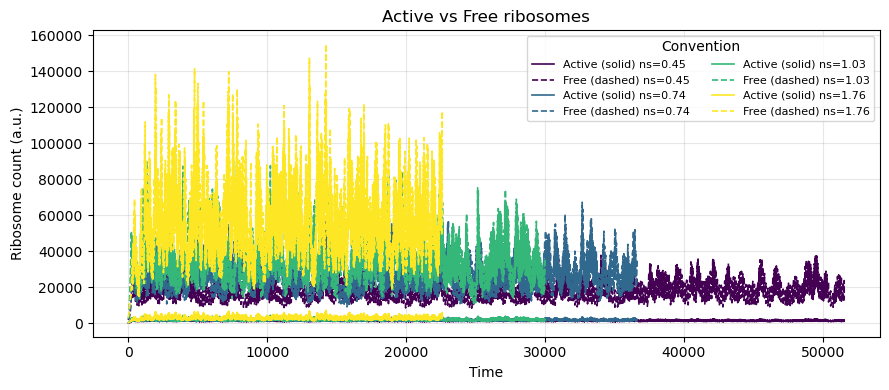

In [16]:
# --- sanity check + clear plot styles ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa, pyarrow.ipc as ipc

files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

def read_arrow(f):
    with pa.memory_map(f, "r") as s:
        return pa.ipc.open_file(s).read_all().to_pandas()

def get_ribo(df):
    free = df["r(t)"].to_numpy()
    active = sum(df[c].to_numpy() for c in ["rmm(t)","rmt(t)","rmq(t)","rmr(t)"] if c in df)
    return df["timestamp"].to_numpy(), free, active

# 1) Print quick aggregates so we know which is larger
print("== Mean ribosome levels over the whole run ==")
for f, ns in files_with_ns:
    df = read_arrow(f)
    _, free, active = get_ribo(df)
    print(f"ns={ns:.2f}:  mean(active)={active.mean():.1f},  mean(free)={free.mean():.1f}")

# 2) Replot with unambiguous styles/labels
colors = plt.cm.viridis(np.linspace(0,1,len(files_with_ns)))
plt.figure(figsize=(9,4))
for (f, ns), col in zip(files_with_ns, colors):
    t, free, active = get_ribo(read_arrow(f))
    # solid = ACTIVE, dashed = FREE (fixed)
    plt.plot(t, active, color=col, lw=1.2, label=f"Active (solid) ns={ns:.2f}")
    plt.plot(t, free,  color=col, lw=1.2, ls="--", label=f"Free (dashed) ns={ns:.2f}")

plt.title("Active vs Free ribosomes")
plt.xlabel("Time"); plt.ylabel("Ribosome count (a.u.)")
plt.legend(ncol=2, fontsize=8, title="Convention")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


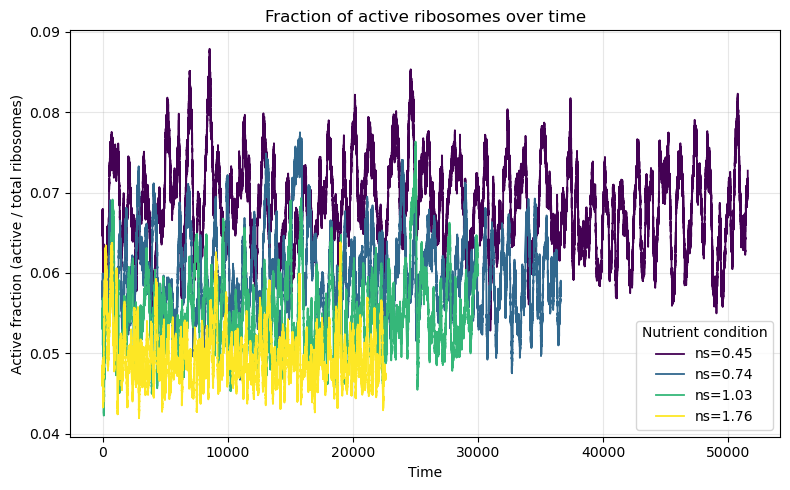

In [17]:
# === Fraction of active ribosomes over time ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa, pyarrow.ipc as ipc

def read_arrow(f):
    with pa.memory_map(f, "r") as s:
        return pa.ipc.open_file(s).read_all().to_pandas()

def compute_fraction(df):
    free = df["r(t)"].to_numpy()
    active = sum(df[c].to_numpy() for c in ["rmm(t)", "rmt(t)", "rmq(t)", "rmr(t)"] if c in df)
    total = free + active
    frac = np.divide(active, total, out=np.zeros_like(active), where=total>0)
    return df["timestamp"].to_numpy(), frac

files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0,1,len(files_with_ns)))

plt.figure(figsize=(8,5))
for (f, ns), col in zip(files_with_ns, colors):
    df = read_arrow(f)
    t, frac = compute_fraction(df)
    plt.plot(t, frac, lw=1.3, color=col, label=f"ns={ns:.2f}")

plt.xlabel("Time")
plt.ylabel("Active fraction (active / total ribosomes)")
plt.title("Fraction of active ribosomes over time")
plt.legend(title="Nutrient condition")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


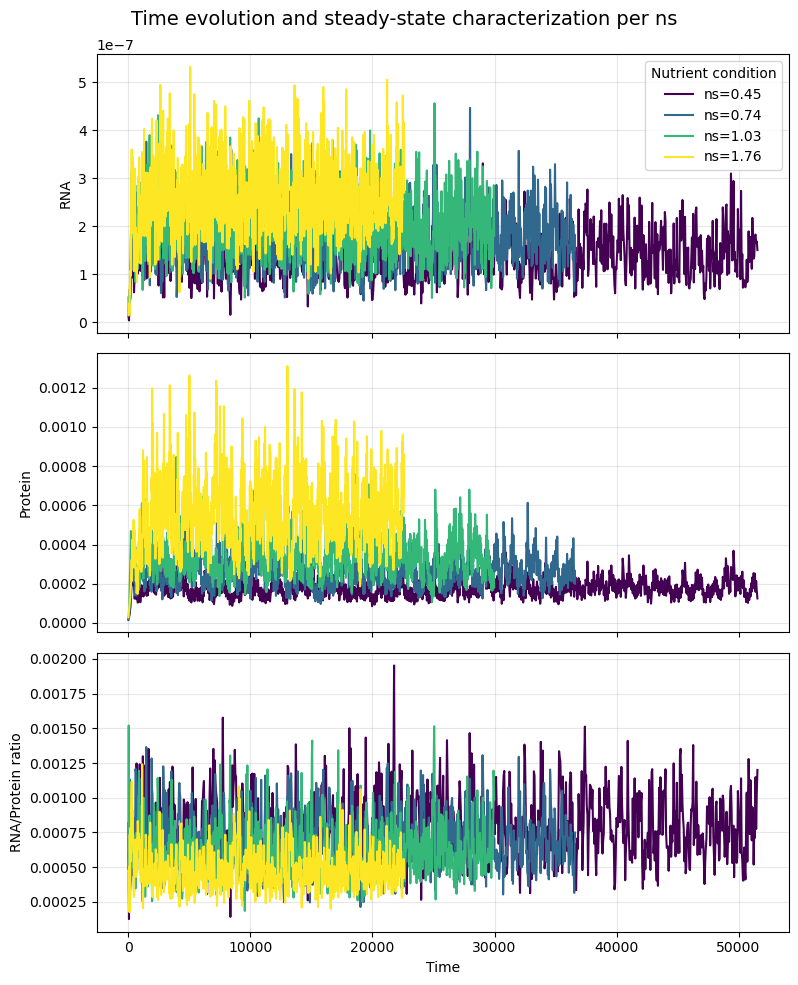

,ns,RNA_mean,RNA_std,Protein_mean,Protein_std,Ratio_mean,Ratio_std
0,0.45,1.416905e-07,5.208153e-08,0.000182,0.000049,0.000782,0.000219
1,0.74,1.844857e-07,5.714483e-08,0.000278,0.000082,0.000681,0.000181
2,1.03,2.026832e-07,6.728839e-08,0.000328,0.000114,0.000644,0.000191
3,1.76,2.575864e-07,6.758672e-08,0.000555,0.000169,0.000486,0.000127


In [7]:
# === Characterize steady-state behavior for each nutrient condition ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

def read_arrow(filename):
    with pa.memory_map(filename, "r") as src:
        return pa.ipc.open_file(src).read_all().to_pandas()

def compute_rna_protein_ratio(df):
    """Compute RNA, Protein, Ratio, and even sampling."""
    RNA = np.zeros(len(df))
    for c in ["mq(t)", "mr(t)"]:
        if c in df.columns:
            RNA += df[c].values/1e8
    Protein = df["r(t)"].values/1e8
    Ratio = np.divide(RNA, Protein, out=np.zeros_like(RNA), where=Protein>0)
    return df["timestamp"].values, RNA, Protein, Ratio

def steady_state_stats(time, values, frac=0.2):
    """Return steady-state mean and std from last `frac` portion of data."""
    k0 = int((1 - frac) * len(values))
    ss_values = values[k0:]
    return np.mean(ss_values), np.std(ss_values)

# Hard-coded mapping
files_with_ns = [
    ("ns045.arrow", 0.45),
    ("ns074.arrow", 0.74),
    ("ns103.arrow", 1.03),
    ("ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))
summaries = []

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
labels = ["RNA", "Protein", "RNA/Protein ratio"]

for (file, ns), color in zip(files_with_ns, colors):
    df = read_arrow(file)
    t, RNA, Protein, Ratio = compute_rna_protein_ratio(df)

    # Equal-distance resampling (1000 uniform points)
    t_resampled = np.linspace(t.min(), t.max(), 1000)
    RNA_resampled = np.interp(t_resampled, t, RNA)
    Protein_resampled = np.interp(t_resampled, t, Protein)
    Ratio_resampled = np.interp(t_resampled, t, Ratio)

    # Compute steady-state stats
    RNA_mean, RNA_std = steady_state_stats(t_resampled, RNA_resampled)
    Prot_mean, Prot_std = steady_state_stats(t_resampled, Protein_resampled)
    Ratio_mean, Ratio_std = steady_state_stats(t_resampled, Ratio_resampled)

    summaries.append(dict(ns=ns,
                          RNA_mean=RNA_mean, RNA_std=RNA_std,
                          Protein_mean=Prot_mean, Protein_std=Prot_std,
                          Ratio_mean=Ratio_mean, Ratio_std=Ratio_std))

    # Plot over time
    axes[0].plot(t_resampled, RNA_resampled, color=color, label=f"ns={ns}")
    axes[1].plot(t_resampled, Protein_resampled, color=color)
    axes[2].plot(t_resampled, Ratio_resampled, color=color)

for i, label in enumerate(labels):
    axes[i].set_ylabel(label)
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel("Time")
axes[0].legend(title="Nutrient condition")

plt.suptitle("Time evolution and steady-state characterization per ns", fontsize=14)
plt.tight_layout()
plt.show()

# === Summary table ===
summary_df = pd.DataFrame(summaries)
display(summary_df)


ns = 0.45, k = 5
  free/active = 1.9439
  free/total  = 0.6603
ns = 0.45, k = 10
  free/active = 0.4720
  free/total  = 0.3206
ns = 0.45, k = 15
  free/active = -0.0187
  free/total  = -0.0191
ns = 0.74, k = 5
  free/active = 2.3801
  free/total  = 0.7041
ns = 0.74, k = 10
  free/active = 0.6900
  free/total  = 0.4083
ns = 0.74, k = 15
  free/active = 0.1267
  free/total  = 0.1124
ns = 1.03, k = 5
  free/active = 2.6899
  free/total  = 0.7290
ns = 1.03, k = 10
  free/active = 0.8449
  free/total  = 0.4580
ns = 1.03, k = 15
  free/active = 0.2300
  free/total  = 0.1870
ns = 1.76, k = 5
  free/active = 3.0849
  free/total  = 0.7552
ns = 1.76, k = 10
  free/active = 1.0424
  free/total  = 0.5104
ns = 1.76, k = 15
  free/active = 0.3616
  free/total  = 0.2656


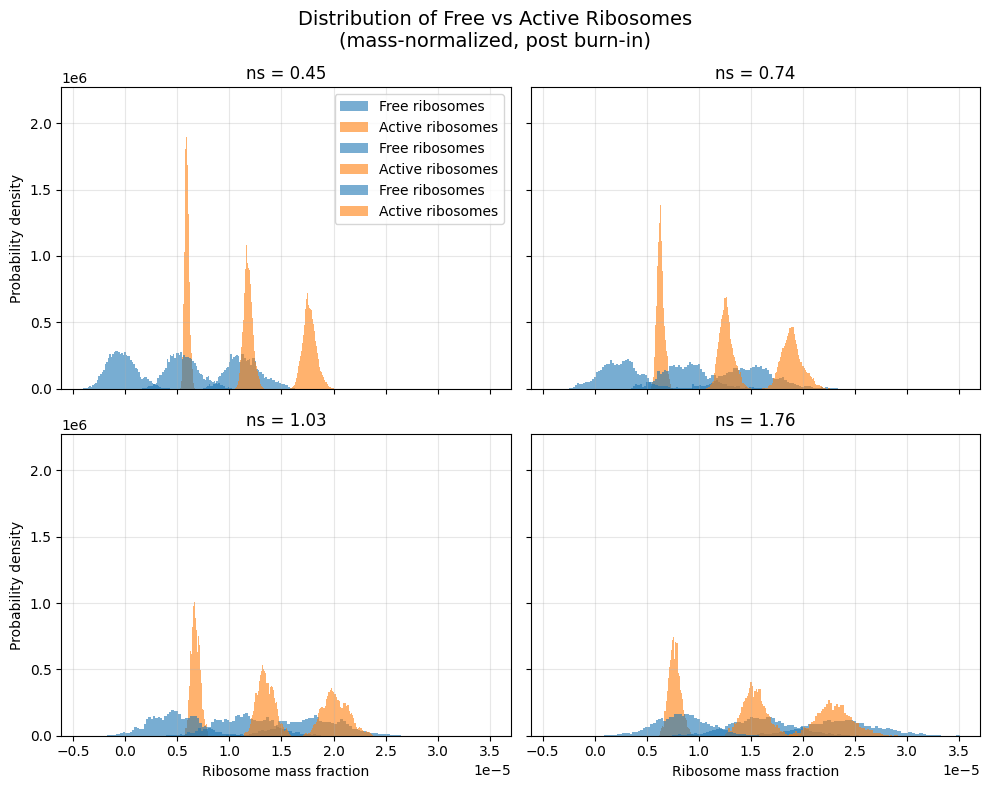

In [4]:
# === Free vs Active Ribosomes: Histograms (mass-normalized, burn-in removed) ===

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ---------- CONSTANTS ----------
NR = 7549.0      # ribosomal protein size (AA)
NX = 300.0       # average non-ribosomal protein size (AA)
BURN_IN = 1000.0 # minutes

# ---------- Load Arrow ----------
def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ---------- Compute Total Mass ----------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)

    return ribo_mass + non_ribo_mass

# ---------- Compute RNA + Ribosomes (mass-normalized) ----------
def compute_rna_ribo(df, mass, k):
    # RNA mass fraction
    RNA = np.zeros(len(df))
    for col in ["mm(t)", "mt(t)", "mq(t)", "mr(t)"]:
        RNA += df[col].values / mass

    # Ribosomes
    free_ribo = df["r(t)"].values / mass
    bound = (
        df["rmm(t)"].values +
        df["rmt(t)"].values +
        df["rmq(t)"].values +
        df["rmr(t)"].values
    ) / mass

    # Polysome correction
    free_ribo   = free_ribo - (k - 1) * bound
    active_ribo = k * bound

    total_ribo = free_ribo + active_ribo
    return RNA, total_ribo, free_ribo, active_ribo

# ---------- Files ----------
files_with_ns = [
    ("Data/ns045.arrow", 0.45),
    ("Data/ns074.arrow", 0.74),
    ("Data/ns103.arrow", 1.03),
    ("Data/ns176.arrow", 1.76),
]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_with_ns)))

# ---------- Histogram Plot ----------
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()
bins = 60

for ax, ((filename, ns), color) in zip(axes, zip(files_with_ns, colors)):
    df = read_arrow(filename)

    # ---- Remove burn-in ----
    df = df.loc[df["timestamp"] >= BURN_IN].copy()

    mass = compute_mass(df)
    for k in [5, 10, 15]:
        _, _, free_ribo, active_ribo = compute_rna_ribo(df, mass, k)

        ratio = np.mean(free_ribo) / np.mean(active_ribo)
        fraction = np.mean(free_ribo) / np.mean(free_ribo + active_ribo)

        print(f"ns = {ns}, k = {k}")
        print(f"  free/active = {ratio:.4f}")
        print(f"  free/total  = {fraction:.4f}")

        ax.hist(
            free_ribo,
            bins=bins,
            density=True,
            alpha=0.6,
            color="tab:blue",
            label="Free ribosomes"
        )
        ax.hist(
            active_ribo,
            bins=bins,
            density=True,
            alpha=0.6,
            color="tab:orange",
            label="Active ribosomes"
        )

        ax.set_title(f"ns = {ns}")
        ax.grid(alpha=0.3)

# ---------- Formatting ----------
axes[0].set_ylabel("Probability density")
axes[2].set_ylabel("Probability density")
axes[2].set_xlabel("Ribosome mass fraction")
axes[3].set_xlabel("Ribosome mass fraction")

axes[0].legend()
fig.suptitle(
    "Distribution of Free vs Active Ribosomes\n(mass-normalized, post burn-in)",
    fontsize=14
)

plt.tight_layout()
plt.show()


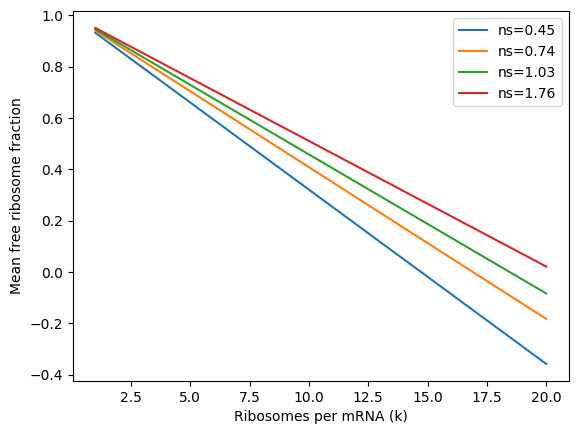

In [5]:
k_values = np.arange(1, 21)

for filename, ns in files_with_ns:
    df = read_arrow(filename)
    df = df.loc[df["timestamp"] >= BURN_IN]
    mass = compute_mass(df)

    fractions = []

    for k in k_values:
        _, _, free_ribo, active_ribo = compute_rna_ribo(df, mass, k)
        fraction = np.mean(free_ribo) / np.mean(free_ribo + active_ribo)
        fractions.append(fraction)

    plt.plot(k_values, fractions, label=f"ns={ns}")

plt.xlabel("Ribosomes per mRNA (k)")
plt.ylabel("Mean free ribosome fraction")
plt.legend()
plt.show()

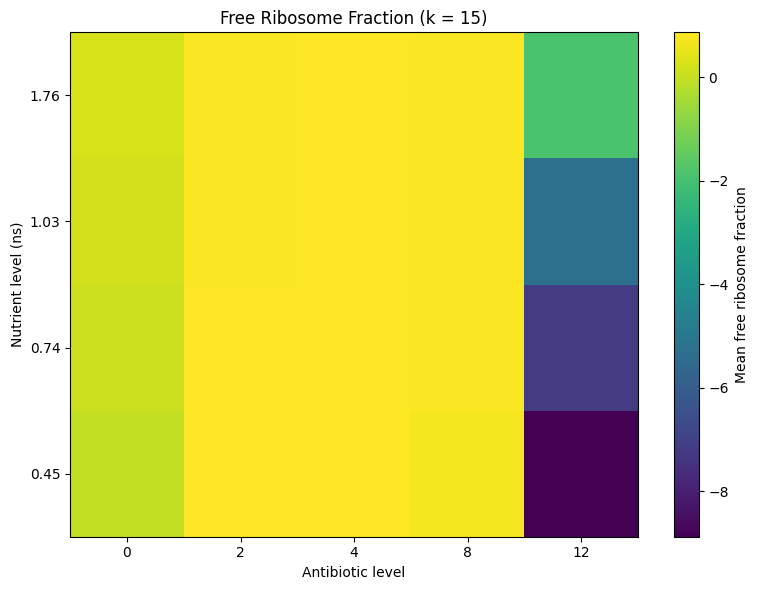

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ===============================
# CONSTANTS
# ===============================

NR = 7549.0
NX = 300.0
BURN_IN = 1000.0
K_POLYSOME = 15  # change to 5 or 15 if desired

# Nutrient levels
ns_levels = [0.45, 0.74, 1.03, 1.76]

# Antibiotic levels (adjust to match your dataset)
abx_levels = [0, 2, 4, 8, 12]

# ===============================
# FILE READER
# ===============================

def read_arrow(filename: str):
    with pa.memory_map(filename, "r") as source:
        return pa.ipc.open_file(source).read_all().to_pandas()

# ===============================
# MASS CALCULATION
# ===============================

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()

    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_mass = NX * (q + et + em)

    return ribo_mass + non_ribo_mass

# ===============================
# RIBOSOME CALCULATION
# ===============================

def compute_ribosomes(df, mass, k):
    free_ribo = df["r(t)"].values / mass

    bound = (
        df["rmm(t)"].values +
        df["rmt(t)"].values +
        df["rmq(t)"].values +
        df["rmr(t)"].values
    ) / mass

    # Polysome correction
    free_ribo   = free_ribo - (k - 1) * bound
    active_ribo = k * bound

    total = free_ribo + active_ribo

    return free_ribo, active_ribo, total

# ===============================
# BUILD HEATMAP MATRIX
# ===============================

heatmap = np.zeros((len(ns_levels), len(abx_levels)))

for i, ns in enumerate(ns_levels):
    for j, abx in enumerate(abx_levels):

        filename = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        try:
            df = read_arrow(filename)
        except:
            heatmap[i, j] = np.nan
            continue

        df = df.loc[df["timestamp"] >= BURN_IN]
        mass = compute_mass(df)

        free_ribo, active_ribo, total = compute_ribosomes(df, mass, K_POLYSOME)

        fraction = np.mean(free_ribo) / np.mean(total)

        heatmap[i, j] = fraction

# ===============================
# PLOT HEATMAP
# ===============================

plt.figure(figsize=(8, 6))

im = plt.imshow(
    heatmap,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(im, label="Mean free ribosome fraction")

plt.xticks(range(len(abx_levels)), abx_levels)
plt.yticks(range(len(ns_levels)), ns_levels)

plt.xlabel("Antibiotic level")
plt.ylabel("Nutrient level (ns)")
plt.title(f"Free Ribosome Fraction (k = {K_POLYSOME})")

plt.tight_layout()
plt.show()